In [1]:
import pandas as pd
 
df_train = pd.read_csv("../content/train.csv")
df_train
df_train.info()
df_train.describe(include="all")
missing_values = df_train.isnull().sum()
missing_values[missing_values > 0]

<class 'pandas.DataFrame'>
RangeIndex: 745305 entries, 0 to 745304
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                745305 non-null  int64  
 1   FloodProbability  745305 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 11.4 MB


Series([], dtype: int64)

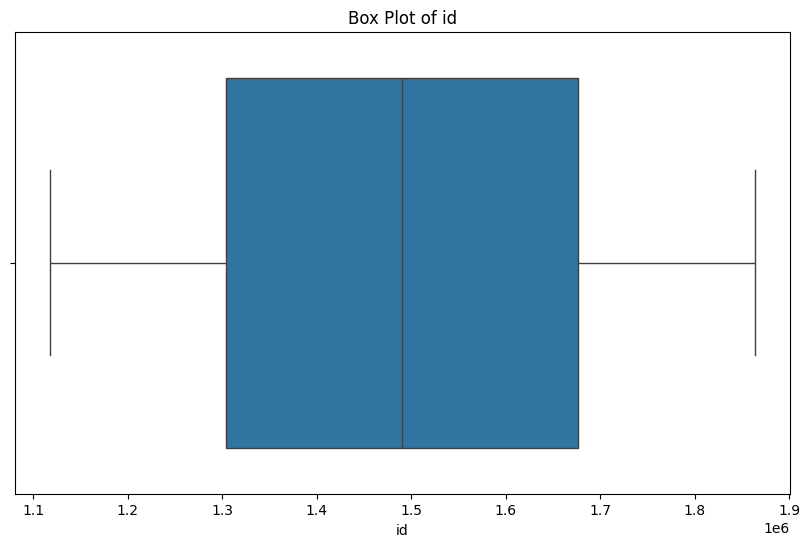

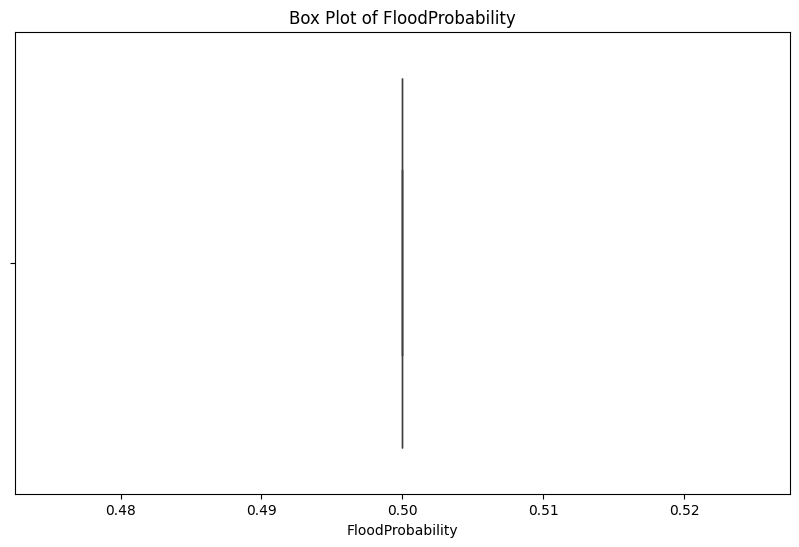

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
for feature in df_train.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df_train[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

Q1 = df_train.quantile(0.25)
Q3 = df_train.quantile(0.75)
IQR = Q3 - Q1
condition = ~((df_train < (Q1 - 1.5 * IQR)) | (df_train > (Q3 + 1.5 * IQR))).any(axis=1)
df = df_train.loc[condition, df_train.columns]

In [6]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer # Mengimpor KElbowVisualizer untuk visualisasi metode Elbow
from sklearn.datasets import make_blobs

# Membuat dataset buatan
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(1,10))
visualizer.fit(X)
visualizer.show()

YellowbrickTypeError: The supplied model is not a clustering estimator; try a classifier or regression score visualizer instead!